In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\faisa\OneDrive\Desktop\AI\venv\Scripts\python.exe
3.13.6 (tags/v3.13.6:4e66535, Aug  6 2025, 14:36:00) [MSC v.1944 64 bit (AMD64)]


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries working")

Libraries working


In [16]:
print("Hello")

Hello


In [17]:
df = pd.read_csv('../data/survey.csv')

In [18]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [19]:
df.shape

(1259, 27)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

state,comment these column having many null value so drop these in data cleaning section

In [21]:
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [22]:
df.drop(columns=['state','comments','Timestamp'],inplace=True)

In [23]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence']

In [24]:
df.describe()


,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [25]:
df[df['Age']<0]

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
143,-29,Male,United States,No,No,No,NaN,More than 1000,Yes,No,...,Don't know,Don't know,No,No,Some of them,Yes,No,No,Don't know,No
715,-1726,male,United Kingdom,No,No,Yes,Sometimes,26-100,No,No,...,Don't know,Somewhat difficult,Yes,No,No,No,No,Maybe,Don't know,No
1127,-1,p,United States,Yes,Yes,Yes,Often,1-5,Yes,Yes,...,Yes,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes


**EDA**

Age column have outlayers


<Axes: ylabel='Age'>

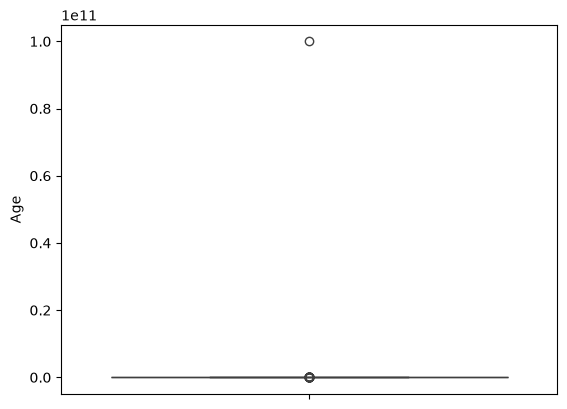

In [26]:
sns.boxplot(df['Age'])

Gendar have many type of value

In [27]:
df['Gender'].value_counts()

Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Cis Male                                            2
Female                                              2
Man                                                 2
Female (trans)                                      2
Male-ish                                            1
maile                                               1
Trans-female                                        1
Cis Female           

In country column need feature engineering

In [28]:
df['Country'].value_counts()

Country
United States             751
United Kingdom            185
Canada                     72
Germany                    45
Netherlands                27
Ireland                    27
Australia                  21
France                     13
India                      10
New Zealand                 8
Switzerland                 7
Poland                      7
Italy                       7
Sweden                      7
Brazil                      6
South Africa                6
Belgium                     6
Israel                      5
Bulgaria                    4
Singapore                   4
Russia                      3
Mexico                      3
Austria                     3
Finland                     3
Portugal                    2
Colombia                    2
Croatia                     2
Denmark                     2
Greece                      2
Slovenia                    1
Costa Rica                  1
Latvia                      1
Romania                     1
Zi

In [29]:
df.columns

Index(['Age', 'Gender', 'Country', 'self_employed', 'family_history',
       'treatment', 'work_interfere', 'no_employees', 'remote_work',
       'tech_company', 'benefits', 'care_options', 'wellness_program',
       'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
       'phys_health_consequence', 'coworkers', 'supervisor',
       'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence'],
      dtype='str')

self_employed column need some research

In [30]:
df['self_employed'].unique().tolist()

[nan, 'Yes', 'No']

self_employed have 18 NaN value this selction need mode fillna

In [31]:
df['self_employed'].value_counts(dropna=False)

self_employed
No     1095
Yes     146
NaN      18
Name: count, dtype: int64

In [32]:
df['self_employed'].value_counts(dropna=False)

self_employed
No     1095
Yes     146
NaN      18
Name: count, dtype: int64

In [33]:
df['family_history'].value_counts()

family_history
No     767
Yes    492
Name: count, dtype: int64

<Axes: ylabel='family_history'>

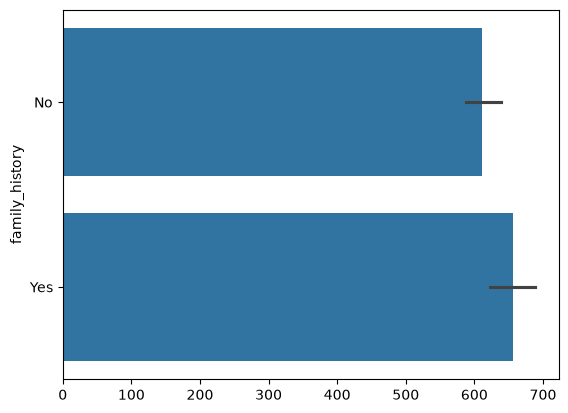

In [34]:
sns.barplot(df['family_history'])

<Axes: xlabel='family_history', ylabel='count'>

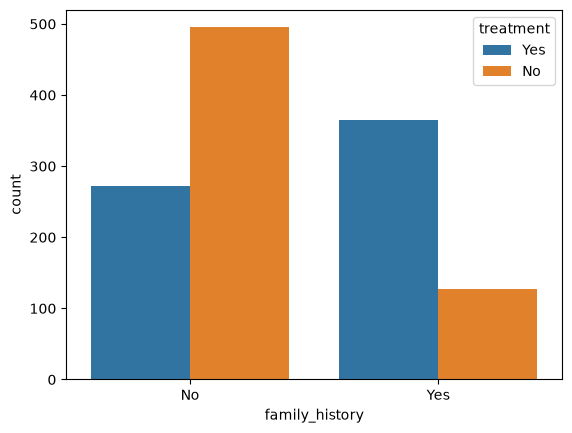

In [35]:

sns.countplot(x=df['family_history'],hue=df['treatment'])

In [36]:
df.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,M,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


work_interfere have many nan value

In [37]:
df['work_interfere'].value_counts(dropna=False)

work_interfere
Sometimes    465
NaN          264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64

In [38]:
df['work_interfere']=df['work_interfere'].fillna('Unknown')

In [39]:
df['no_employees'].value_counts(dropna=False)

no_employees
6-25              290
26-100            289
More than 1000    282
100-500           176
1-5               162
500-1000           60
Name: count, dtype: int64

In [40]:
df['remote_work'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

<Axes: xlabel='remote_work', ylabel='count'>

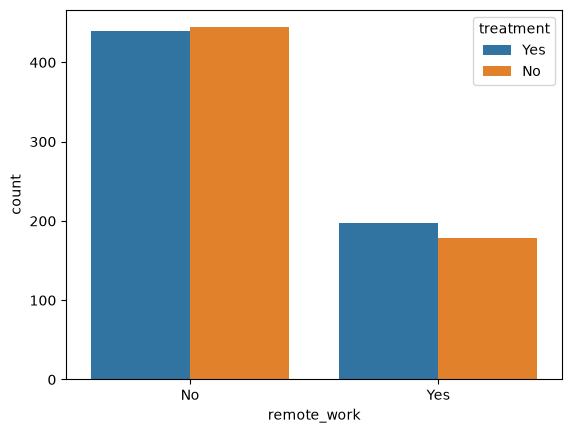

In [41]:
sns.countplot(x=df['remote_work'],hue=df['treatment'])

In [42]:
df['tech_company'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

<Axes: xlabel='tech_company', ylabel='count'>

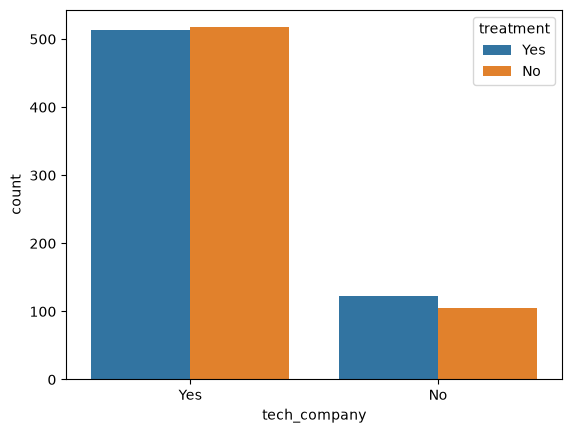

In [43]:
sns.countplot(x=df['tech_company'],hue=df['treatment'])

In [44]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'self_employed',
 'family_history',
 'treatment',
 'work_interfere',
 'no_employees',
 'remote_work',
 'tech_company',
 'benefits',
 'care_options',
 'wellness_program',
 'seek_help',
 'anonymity',
 'leave',
 'mental_health_consequence',
 'phys_health_consequence',
 'coworkers',
 'supervisor',
 'mental_health_interview',
 'phys_health_interview',
 'mental_vs_physical',
 'obs_consequence']

In [45]:
df['benefits'].unique()

<StringArray>
['Yes', 'Don't know', 'No']
Length: 3, dtype: str

<Axes: xlabel='benefits', ylabel='count'>

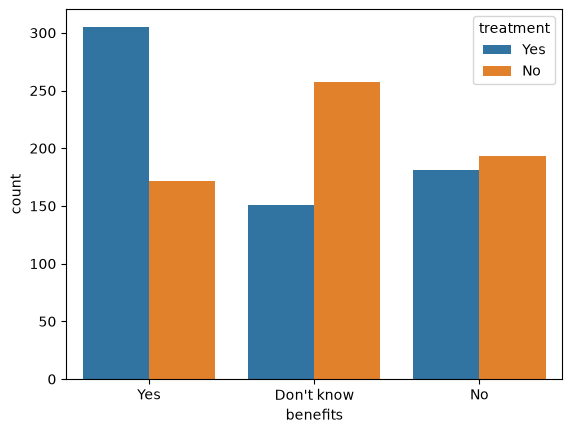

In [46]:
sns.countplot(x=df['benefits'],hue=df['treatment'])

In [47]:
df['care_options'].unique()

<StringArray>
['Not sure', 'No', 'Yes']
Length: 3, dtype: str

In [48]:
df['care_options'].value_counts(dropna=False)

care_options
No          501
Yes         444
Not sure    314
Name: count, dtype: int64

In [49]:
df['wellness_program'].unique()

<StringArray>
['No', 'Don't know', 'Yes']
Length: 3, dtype: str

In [50]:
df['wellness_program'].value_counts(dropna=False)

wellness_program
No            842
Yes           229
Don't know    188
Name: count, dtype: int64

In [51]:
df['seek_help'].unique()

<StringArray>
['Yes', 'Don't know', 'No']
Length: 3, dtype: str

In [52]:
df['seek_help'].value_counts(dropna=False)

seek_help
No            646
Don't know    363
Yes           250
Name: count, dtype: int64

In [53]:
df['anonymity'].value_counts(dropna=False)

anonymity
Don't know    819
Yes           375
No             65
Name: count, dtype: int64

In [54]:
df['leave'].unique()

<StringArray>
[     'Somewhat easy',         'Don't know', 'Somewhat difficult',
     'Very difficult',          'Very easy']
Length: 5, dtype: str

In [55]:
df['leave'].value_counts(dropna=False)

leave
Don't know            563
Somewhat easy         266
Very easy             206
Somewhat difficult    126
Very difficult         98
Name: count, dtype: int64

In [56]:
df['mental_health_consequence'].value_counts(dropna=False)

mental_health_consequence
No       490
Maybe    477
Yes      292
Name: count, dtype: int64

In [57]:
df['phys_health_consequence'].value_counts(dropna=False)

phys_health_consequence
No       925
Maybe    273
Yes       61
Name: count, dtype: int64

In [58]:
df['coworkers'].value_counts(dropna=False)

coworkers
Some of them    774
No              260
Yes             225
Name: count, dtype: int64

In [59]:
df['supervisor'].value_counts(dropna=False)

supervisor
Yes             516
No              393
Some of them    350
Name: count, dtype: int64

In [60]:
df['mental_health_interview'].value_counts(dropna=False)

mental_health_interview
No       1008
Maybe     207
Yes        44
Name: count, dtype: int64

In [61]:
df['phys_health_interview'].value_counts(dropna=False)

phys_health_interview
Maybe    557
No       500
Yes      202
Name: count, dtype: int64

In [62]:
df['mental_vs_physical'].value_counts(dropna=False)

mental_vs_physical
Don't know    576
Yes           343
No            340
Name: count, dtype: int64

In [63]:
df['obs_consequence'].value_counts(dropna=False)


obs_consequence
No     1075
Yes     184
Name: count, dtype: int64

**Data Cleaning**

In [64]:
df[df['Age'] < 15]

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
143,-29,Male,United States,No,No,No,Unknown,More than 1000,Yes,No,...,Don't know,Don't know,No,No,Some of them,Yes,No,No,Don't know,No
715,-1726,male,United Kingdom,No,No,Yes,Sometimes,26-100,No,No,...,Don't know,Somewhat difficult,Yes,No,No,No,No,Maybe,Don't know,No
734,5,Male,United States,No,No,No,Unknown,100-500,No,Yes,...,Don't know,Somewhat easy,No,No,Yes,Yes,No,No,Yes,No
989,8,A little about you,"Bahamas, The",Yes,Yes,Yes,Often,1-5,Yes,Yes,...,Yes,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1090,11,male,United States,Yes,No,No,Never,1-5,Yes,Yes,...,Yes,Very easy,No,No,Some of them,Some of them,No,Maybe,Yes,No
1127,-1,p,United States,Yes,Yes,Yes,Often,1-5,Yes,Yes,...,Yes,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes


In [65]:
df[df['Age'] > 100]

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
364,329,Male,United States,No,No,Yes,Often,6-25,Yes,Yes,...,Don't know,Don't know,Maybe,No,Some of them,No,No,No,No,No
390,99999999999,All,Zimbabwe,Yes,Yes,Yes,Often,1-5,No,Yes,...,No,Very difficult,Yes,Yes,No,No,Yes,No,No,Yes


In [66]:
df[(df['Age'] < 15) | (df['Age'] > 100)]

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
143,-29,Male,United States,No,No,No,Unknown,More than 1000,Yes,No,...,Don't know,Don't know,No,No,Some of them,Yes,No,No,Don't know,No
364,329,Male,United States,No,No,Yes,Often,6-25,Yes,Yes,...,Don't know,Don't know,Maybe,No,Some of them,No,No,No,No,No
390,99999999999,All,Zimbabwe,Yes,Yes,Yes,Often,1-5,No,Yes,...,No,Very difficult,Yes,Yes,No,No,Yes,No,No,Yes
715,-1726,male,United Kingdom,No,No,Yes,Sometimes,26-100,No,No,...,Don't know,Somewhat difficult,Yes,No,No,No,No,Maybe,Don't know,No
734,5,Male,United States,No,No,No,Unknown,100-500,No,Yes,...,Don't know,Somewhat easy,No,No,Yes,Yes,No,No,Yes,No
989,8,A little about you,"Bahamas, The",Yes,Yes,Yes,Often,1-5,Yes,Yes,...,Yes,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
1090,11,male,United States,Yes,No,No,Never,1-5,Yes,Yes,...,Yes,Very easy,No,No,Some of them,Some of them,No,Maybe,Yes,No
1127,-1,p,United States,Yes,Yes,Yes,Often,1-5,Yes,Yes,...,Yes,Very easy,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes


In [67]:
df = df[(df['Age']>=15) & (df['Age']<=100)]

In [68]:
df.describe()

,Age
count,1251.000000
mean,32.076739
std,7.288272
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


In [69]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [70]:
df.describe()

,Age
count,1251.000000
mean,32.076739
std,7.288272
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


<Axes: ylabel='Age'>

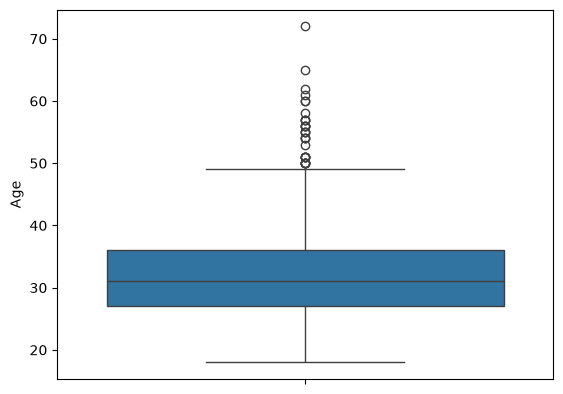

In [71]:
sns.boxplot(df['Age'])

In [72]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

print(lower_bound)
print(upper_bound)

13.5
49.5


In [73]:
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]
print(outliers.shape[0])

32


In [74]:
df['Gender'] = df['Gender'].str.strip().str.lower()

In [75]:
df['Gender'].unique()

<StringArray>
[                                        'female',
                                              'm',
                                           'male',
                                       'male-ish',
                                          'maile',
                                   'trans-female',
                                     'cis female',
                                              'f',
                          'something kinda male?',
                                       'cis male',
                                          'woman',
                                            'mal',
                                     'male (cis)',
                                 'queer/she/they',
                                     'non-binary',
                                         'femake',
                                           'make',
                                            'nah',
                                           'enby',
                 

In [76]:
male = [
    'm',
    'male',
    'male-ish',
    'maile',
    'something kinda male?',
    'cis male',
    'mal',
    'male (cis)',
    'make',
    'guy (-ish) ^_^',
    'male leaning androgynous',
    'man',
    'msle',
    'mail',
    'malr',
    'cis man',
    'ostensibly male, unsure what that really means'
]

female = [
    'female',
    'f',
    'woman',
    'trans-female',
    'trans woman',
    'female (trans)',
    'cis female',
    'cis-female/femme',
    'female (cis)',
    'femake',
    'femail'
]


other = [
    'queer/she/they',
    'non-binary',
    'nah',
    'all',
    'enby',
    'fluid',
    'genderqueer',
    'androgyne',
    'agender',
    'neuter',
    'queer',
    'a little about you',
    'p'
]

df.loc[df['Gender'].isin(male), 'Gender'] = 'Male'
df.loc[df['Gender'].isin(female),'Gender']='Female'
df.loc[df['Gender'].isin(other),'Gender']='Other'

In [77]:
df['Gender'].unique()

<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

In [78]:
df['Gender'].value_counts(dropna=False)

Gender
Male      990
Female    251
Other      10
Name: count, dtype: int64

In [79]:
df.info()

<class 'pandas.DataFrame'>
Index: 1251 entries, 0 to 1258
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Age                        1251 non-null   int64
 1   Gender                     1251 non-null   str  
 2   Country                    1251 non-null   str  
 3   self_employed              1233 non-null   str  
 4   family_history             1251 non-null   str  
 5   treatment                  1251 non-null   str  
 6   work_interfere             1251 non-null   str  
 7   no_employees               1251 non-null   str  
 8   remote_work                1251 non-null   str  
 9   tech_company               1251 non-null   str  
 10  benefits                   1251 non-null   str  
 11  care_options               1251 non-null   str  
 12  wellness_program           1251 non-null   str  
 13  seek_help                  1251 non-null   str  
 14  anonymity                  1251 non-null

In [80]:
df['Age'] = df['Age'].astype(int)

**Feature engineering**

In [81]:
Top_country = df['Country'].value_counts().index[:10].tolist()
Top_country

['United States',
 'United Kingdom',
 'Canada',
 'Germany',
 'Netherlands',
 'Ireland',
 'Australia',
 'France',
 'India',
 'New Zealand']

In [82]:
def Grouped_country(x):
  if x in Top_country:
    return x
  else:
    return 'Other'

In [83]:
df['Grouped_country'] = df['Country'].apply(Grouped_country)

In [84]:
df['Grouped_country'].value_counts()

Grouped_country
United States     746
United Kingdom    184
Other              98
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64

In [85]:
df.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Grouped_country
0,37,Female,United States,NaN,No,Yes,Often,6-25,No,Yes,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,United States
1,44,Male,United States,NaN,No,No,Rarely,More than 1000,No,No,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,United States
2,32,Male,Canada,NaN,No,No,Rarely,6-25,No,Yes,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,Canada
3,31,Male,United Kingdom,NaN,Yes,Yes,Often,26-100,No,Yes,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,United Kingdom
4,31,Male,United States,NaN,No,No,Never,100-500,Yes,Yes,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,United States


In [86]:
df['self_employed'].value_counts(dropna=False)

self_employed
No     1091
Yes     142
NaN      18
Name: count, dtype: int64

In [87]:
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

**Encoding Stategy**

In [88]:
df['treatment'].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [89]:
df['treatment'] = df['treatment'].map({
    'Yes' : 1,
    'No' :0
})

In [90]:
from sklearn.model_selection import train_test_split

num_cols = ['Age']
cat_cols = df.drop(columns=['Age', 'Country', 'treatment']).columns.tolist()

X = df[num_cols + cat_cols]
y = df['treatment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Preprocessing using ColumnTransformer**

In [91]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, num_cols),
    ('nominal', nominal_pipeline, cat_cols)
])

**LinearRegression Model**

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Import classification metrics


lr_pipeline = Pipeline(steps=[
    ('preprocessor',clone(preprocessor)),
    ('model',LogisticRegression())
])

lr_pipeline.fit(X_train,y_train)

lr_pred = lr_pipeline.predict(X_test)
lr_train =lr_pipeline.predict(X_train)

# Use appropriate classification metrics for a classification problem
lr_accuracy_train = accuracy_score(y_train,lr_train)
lr_accuracy_test = accuracy_score(y_test,lr_pred)
lr_precision_test = precision_score(y_test, lr_pred)
lr_recall_test = recall_score(y_test, lr_pred)
lr_f1_test = f1_score(y_test, lr_pred)


print(f'Accuracy of training: {lr_accuracy_train}')
print(f'Accuracy of testing: {lr_accuracy_test}')
print(f'Precision of testing: {lr_precision_test}')
print(f'Recall of testing: {lr_recall_test}')
print(f'F1-score of testing: {lr_f1_test}')

Accuracy of training: 0.858
Accuracy of testing: 0.8047808764940239
Precision of testing: 0.8068965517241379
Recall of testing: 0.8478260869565217
F1-score of testing: 0.8268551236749117


c:\Users\faisa\OneDrive\Desktop\AI\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


**Randomforest model**

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Import classification metrics


rf_pipeline = Pipeline(steps=[
    ('preprocessor',clone(preprocessor)),
    ('model',RandomForestClassifier(n_estimators=100,max_depth=30,min_samples_split=9,min_samples_leaf=2))
])


rf_pipeline.fit(X_train,y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_train =rf_pipeline.predict(X_train)


rf_accuracy_train = accuracy_score(y_train,rf_train)
rf_accuracy_test = accuracy_score(y_test,rf_pred)
rf_precision_test = precision_score(y_test, rf_pred)
rf_recall_test = recall_score(y_test, rf_pred)
rf_f1_test = f1_score(y_test, rf_pred)


print(f"Accuracy of training: {rf_accuracy_train}")
print(f"Accuracy of testing: {rf_accuracy_test}")
print(f"Precision of testing: {rf_precision_test}")
print(f"Recall of testing: {rf_recall_test}")
print(f"F1-score of testing: {rf_f1_test}")


Accuracy of training: 0.923
Accuracy of testing: 0.7848605577689243
Precision of testing: 0.7763157894736842
Recall of testing: 0.855072463768116
F1-score of testing: 0.8137931034482758


In [94]:
from sklearn.model_selection import cross_val_score

score =cross_val_score(rf_pipeline,X_train,y_train,cv=5)
print("Cross validation accuracy",score)
print("Mean accuracy",score.mean())

Cross validation accuracy [0.835 0.81  0.855 0.79  0.83 ]
Mean accuracy 0.8240000000000001


**RandomSearchCV**

In [95]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [10,20,30],
     'model__min_samples_split':[2,5,9],
    'model__min_samples_leaf':[1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    random_state=42,
)

random_search.fit(X_train, y_train)



RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Age']),
                                                                              ('nominal',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['Gender',...
                                                                                'mental_vs_physical',
                                                                                'obs_consequence',
                                                                                'Grouped_country'])])),
                                             ('model',
                                              RandomForestClassifier(max_depth=30,
                                                                     min_samples_leaf=2,
                                                                     min_samples_split=9))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 20, 30],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 9],
                                        'model__n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy')

In [96]:
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'model__n_estimators': 50, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 10}
Best Score: 0.8300000000000001


In [97]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score

xgb_pipeline  =Pipeline(steps=[
    ('preprocessor',clone(preprocessor)),
    ('model',XGBClassifier(n_estimators=50,
                           max_depth=3,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1,random_state=42))
])

xgb_pipeline.fit(X_train,y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_train =xgb_pipeline.predict(X_train)


xgb_accuracy_train = accuracy_score(y_train,xgb_train)
xgb_accuracy_test  =accuracy_score(y_test,xgb_pred)


xgb_precision_test = precision_score(y_test, xgb_pred)
xgb_recall_test = recall_score(y_test, xgb_pred)
xgb_f1_test = f1_score(y_test, xgb_pred)


print(f"accuracy of training: {xgb_accuracy_train}")
print(f"accuracy of testing: {xgb_accuracy_test}")
print(f"precision of testing: {xgb_precision_test}")
print(f"recall of testing: {xgb_recall_test}")
print(f"f1_test: {xgb_f1_test}")

accuracy of training: 0.844
accuracy of testing: 0.8247011952191236
precision of testing: 0.7865853658536586
recall of testing: 0.9347826086956522
f1_test: 0.8543046357615894


In [98]:
from sklearn.model_selection import cross_val_score


score = cross_val_score(xgb_pipeline,X_train,y_train,cv=5)
print("Cross validation accuracy",score)
print("Mean accuracy",score.mean())
print("Standard Deviation",score.std())

Cross validation accuracy [0.85  0.85  0.875 0.785 0.82 ]
Mean accuracy 0.8360000000000001
Standard Deviation 0.030886890422960993


In [99]:
roc_score = cross_val_score(xgb_pipeline,X_train,y_train,cv=5,scoring='roc_auc',n_jobs=-1)
print("ROC-AUC Score",roc_score)
print("Mean ROC-AUC Score",roc_score.mean())
print("Standard Deviation",roc_score.std())


ROC-AUC Score [0.90834083 0.90684068 0.92944294 0.85448545 0.91576631]
Mean ROC-AUC Score 0.9029752435027417
Standard Deviation 0.02553092981652056


In [100]:
result =[]
result.append({
    "Model":"LogisticRegression",
    "Accuracy_train":lr_accuracy_train,
    "Accuracy_test":lr_accuracy_test,
    "Precision_test":lr_precision_test,
    "Recall_test":lr_recall_test,
    "F1_test":lr_f1_test
})
result.append({
    "Model":"RandomForest",
    "Accuracy_train":rf_accuracy_train,
    "Accuracy_test":rf_accuracy_test,
    "Precision_test":rf_precision_test,
    "Recall_test":rf_recall_test,
    "F1_test":rf_f1_test
})

result.append({
    "Model":XGBClassifier,
    "Accuracy_train":xgb_accuracy_train,
    "Accuracy_test":xgb_accuracy_test,
    "Precision_test":xgb_precision_test,
    "Recall_test":xgb_recall_test,
    "F1_test":xgb_f1_test
})

In [101]:
mertrics_df = pd.DataFrame(result)
mertrics_df

,Model,Accuracy_train,Accuracy_test,Precision_test,Recall_test,F1_test
0,LogisticRegression,0.858,0.804781,0.806897,0.847826,0.826855
1,RandomForest,0.923,0.784861,0.776316,0.855072,0.813793
2,<class 'xgboost.sklearn.XGBClassifier'>,0.844,0.824701,0.786585,0.934783,0.854305


In [102]:
import sklearn, xgboost
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

sklearn: 1.6.1
xgboost: 3.4.1


In [107]:
import joblib
joblib.dump(xgb_pipeline,'Tretment_prediction.pkl')


['Tretment_prediction.pkl']

In [103]:
df.shape


(1251, 25)

In [109]:
model = joblib.load('Tretment_prediction.pkl')
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'self

In [110]:
sample = X_test.iloc[[30]]
predication = model.predict(sample)
print(predication)

[0]


In [111]:
print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [112]:
print("Steps:")
print(model.named_steps)

Steps:
{'preprocessor': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age']),
                                ('nominal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender', 'self_employed', 'family_history',
                                  'work_interfere', 'no_employees',
                                  'remote_work', 'tech_company', 'benefits',
                                  'care_options', 'wellness_program',
                  

In [113]:
print("Features:")
print(model.feature_names_in_)

Features:
['Age' 'Gender' 'self_employed' 'family_history' 'work_interfere'
 'no_employees' 'remote_work' 'tech_company' 'benefits' 'care_options'
 'wellness_program' 'seek_help' 'anonymity' 'leave'
 'mental_health_consequence' 'phys_health_consequence' 'coworkers'
 'supervisor' 'mental_health_interview' 'phys_health_interview'
 'mental_vs_physical' 'obs_consequence' 'Grouped_country']


In [114]:
print(model.named_steps.keys())

dict_keys(['preprocessor', 'model'])


In [115]:
df.head(1)

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Grouped_country
0,37,Female,United States,No,No,1,Often,6-25,No,Yes,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,United States


In [116]:
df['Grouped_country'].value_counts(dropna=False)

Grouped_country
United States     746
United Kingdom    184
Other              98
Canada             72
Germany            45
Netherlands        27
Ireland            27
Australia          21
France             13
India              10
New Zealand         8
Name: count, dtype: int64

In [117]:
df['self_employed'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [118]:
loaded_model = joblib.load("../models/Tretment_prediction.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [119]:
prediction = loaded_model.predict(X_test)

print(prediction[:10])

[0 1 0 0 0 1 1 0 1 1]
